# COVID-19 India — Exploratory Data Analysis & Case Forecasting

**Goal:** Uncover state-wise trends, recovery rates, and vaccination progress in India's COVID-19 pandemic, then build and validate a short-term **forecasting model** for confirmed cases.

**Data sources** (both loaded live, no download needed):
- **Case data:** `imdevskp/covid-19-india-data` — daily state-wise confirmed/recovered/death counts, sourced from MoHFW and covid19india.org (30 Jan 2020 – 6 Aug 2020).
- **Vaccination data:** Our World in Data (OWID) — India's national vaccination totals (15 Jan 2021 onward).

**Workflow:** Load → Inspect → Clean → Explore (groupby/pivot) → Visualise (12 charts) → **Model & Forecast** → Summarise findings.

> **Note on the data window:** the case dataset covers the first wave of the pandemic in India (through Aug 2020), before vaccines existed. The vaccination dataset picks up separately from Jan 2021. We treat these as two connected parts of the same story: how the outbreak spread state by state, and how the vaccination rollout progressed afterward.

## At a Glance

| Metric | Value |
|---|---|
| Coverage | 35 states/UTs · 186 days (30 Jan – 6 Aug 2020) |
| Total confirmed (end of window) | **19.6 lakh** (1.96M) |
| Total recovered | **13.3 lakh** · Recovery rate **68%** |
| Total deaths | **40,700** · Death rate **2.1%** |
| Worst-hit state | **Maharashtra** (~24% of national cases) |
| Best recovery rate (top-10 states) | **Delhi** (~90%) |
| **Best forecasting model** | **Exponential growth fit** — R² = 0.96, MAPE = 2.2% on a 14-day holdout |
| **Estimated doubling time** | **~19 days**, at the growth rate observed through early Aug 2020 |
| **14-day forward forecast** | Confirmed cases projected to reach **~3.3M by 20 Aug 2020** if the trend held |
| Vaccination (by mid-2024) | 2.2 Bn+ doses · 950M+ fully vaccinated |

*(Full detail, caveats, and the model-comparison table are in Sections 8 and 10.)*

### Table of Contents
1. Setup & Imports
2. Data Acquisition
3. Data Quality Audit
4. Data Cleaning & Feature Engineering
5. National-Level Trends
6. State-Wise Snapshot
7. Exploratory Visual Analysis (12 charts)
8. **Predictive Modelling — Forecasting Confirmed Cases**
9. Persisting the Cleaned Dataset
10. Executive Summary & Key Findings

## 1 | Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

print("Ready.")

Ready.


## 2 | Data Acquisition

We read both CSVs straight from their public GitHub URLs with `pd.read_csv()`.

In [2]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


In [3]:
vax.shape

(1250, 8)

## 3 | Data Quality Audit

Always check shape, dtypes, and missing values first — this tells you exactly what cleaning is needed.

In [4]:
cases.dtypes

Date                             str
Name of State / UT               str
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                            str
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

In [5]:
cases.isna().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [6]:
print("Number of unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Number of unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

Two problems jump out immediately:

1. **`Death` is stored as text (object), not a number** — likely because of stray characters somewhere in the column.
2. **The same state appears under multiple spellings**: `Telangana`, `Telengana`, and `Telangana***` are all the same state. Similarly, a few Union Territories are listed twice — once plainly (`Ladakh`) and once with a `"Union Territory of ..."` prefix.

This is exactly the kind of real-world messiness that needs to be fixed before doing any analysis, never after.

## 4 | Data Cleaning & Feature Engineering

In [7]:
# Rename to clean, snake_case column names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

# Fix data types
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

# Fix inconsistent state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Drop any exact duplicate (date, state) rows this merge might create
cases = cases.drop_duplicates(subset=["date", "state"]).sort_values(["state", "date"]).reset_index(drop=True)

# A derived column: active cases = confirmed - deaths - recovered
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

print("Clean state count:", cases["state"].nunique())
cases.dtypes

Clean state count: 35


date             datetime64[us]
state                       str
lat                     float64
long                    float64
confirmed                 int64
deaths                    int64
cured                     int64
new_cases                 int64
new_deaths                int64
new_recovered             int64
active                    int64
dtype: object

In [8]:
cases.isna().sum().sum()   # should be 0 -- fully clean now

np.int64(0)

## 5 | National-Level Trends

Aggregate all states together, per date, using `groupby`.

In [9]:
national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])

national.tail()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
181,2020-08-02,1750723,37364,1145629,65.44,2.13,54735.0
182,2020-08-03,1803695,38135,1186203,65.77,2.11,52972.0
183,2020-08-04,1855745,38938,1230509,66.31,2.10,52050.0
184,2020-08-05,1908254,39795,1282215,67.19,2.09,52509.0
185,2020-08-06,1964536,40699,1328336,67.62,2.07,56282.0


In [10]:
latest_date = cases["date"].max()
latest_row = national.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['cured']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")

As of 2020-08-06:
  Total confirmed : 1,964,536
  Total recovered : 1,328,336
  Total deaths    : 40,699
  Recovery rate   : 67.62%
  Death rate      : 2.07%


## 6 | State-Wise Snapshot (Latest Date)

In [11]:
latest = cases[cases["date"] == latest_date].copy()
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)
top10[["state", "confirmed", "deaths", "cured", "recovery_rate", "death_rate"]]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


**pivot_table**: confirmed cases by state and month, so we can see when each state's outbreak accelerated.

In [12]:
cases["month"] = cases["date"].dt.strftime("%Y-%m")
month_pivot = cases[cases["state"].isin(top10["state"].head(5))].pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


## 7 | Exploratory Visual Analysis

We work through national trends, state comparisons, and relationships between metrics using both Matplotlib and Seaborn.

### 7.1 National Cumulative Trend

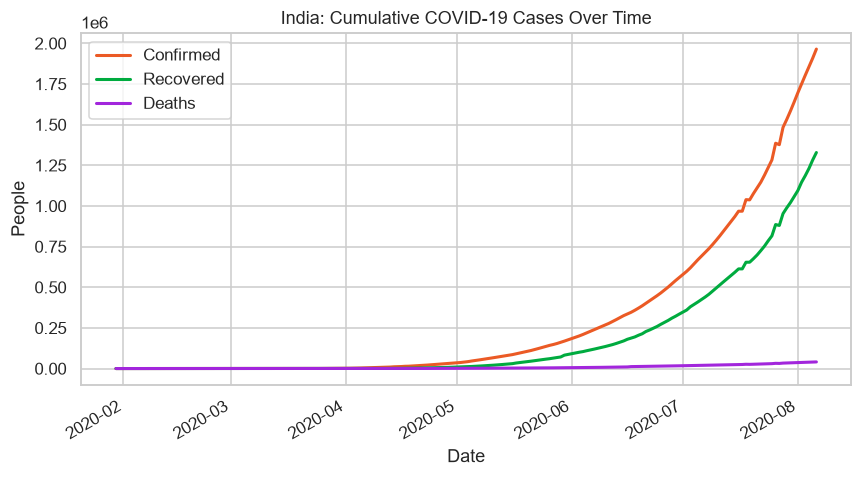

In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["confirmed"], label="Confirmed", color="#eb5a25", lw=2)
ax.plot(national["date"], national["cured"], label="Recovered", color="#00ab3f", lw=2)
ax.plot(national["date"], national["deaths"], label="Deaths", color="#a226dc", lw=2)
ax.set_title("India: Cumulative COVID-19 Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 7.2 Daily New Confirmed Cases

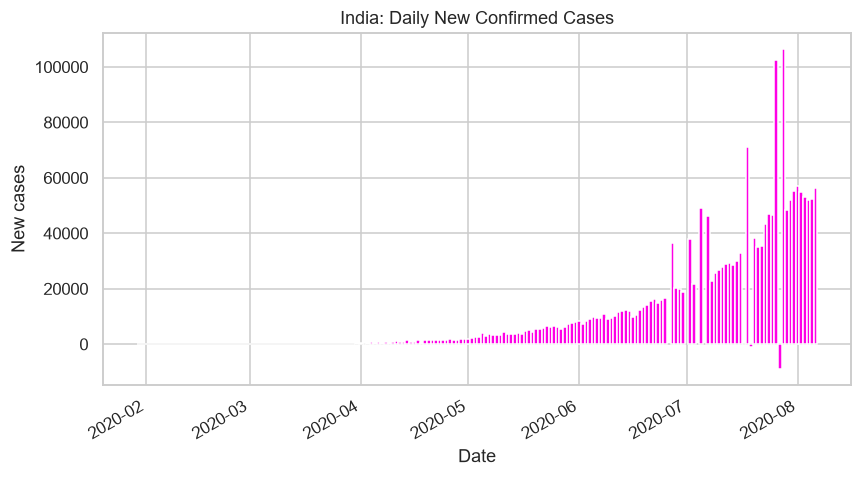

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(national["date"], national["new_confirmed"], color="#ff00e6", width=1.0)
ax.set_title("India: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 7.3 Top 10 States by Total Confirmed Cases

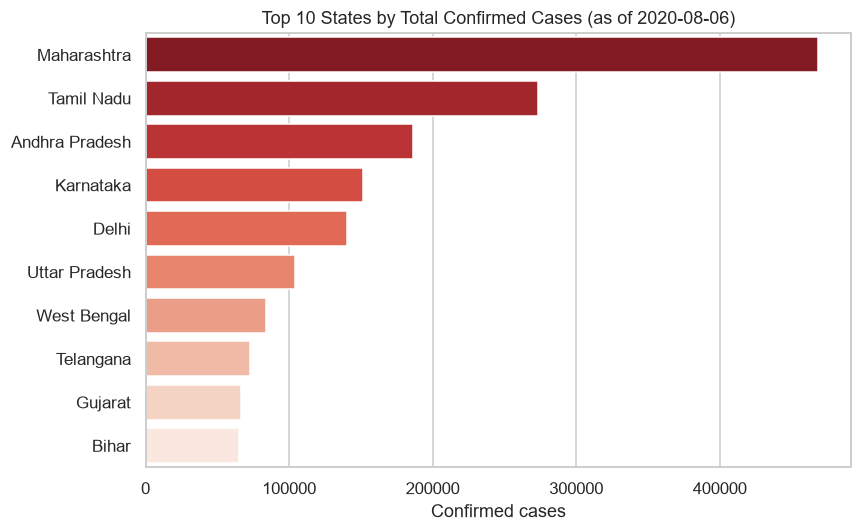

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="state", x="confirmed", hue="state", palette="Reds_r", legend=False, ax=ax)
ax.set_title(f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 7.4 Recovery Rate — 10 Worst-Hit States

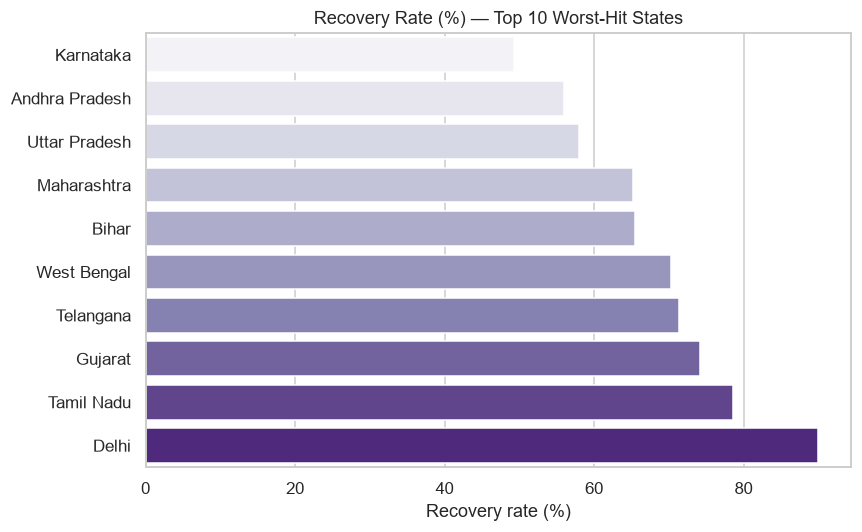

In [33]:
top10_sorted = top10.sort_values("recovery_rate")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_sorted, y="state", x="recovery_rate", hue="state", palette="Purples", legend=False, ax=ax)
ax.set_title("Recovery Rate (%) — Top 10 Worst-Hit States")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 7.5 Confirmed-Case Trajectories — Top 5 States

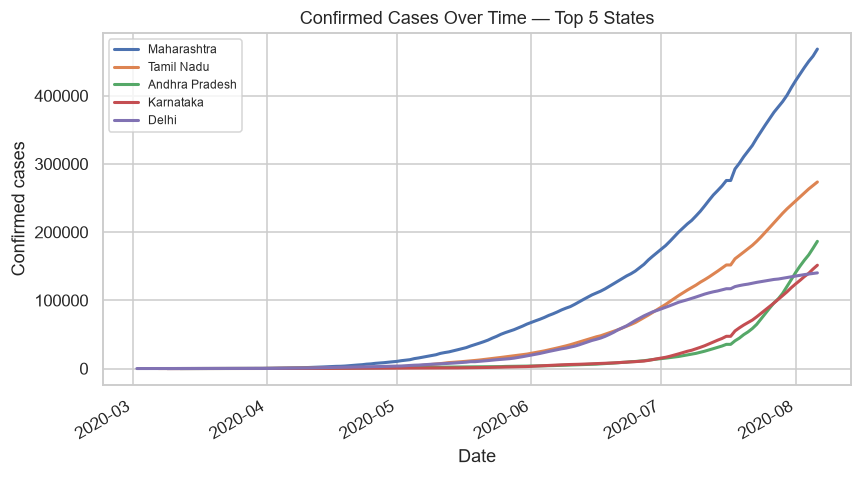

In [17]:
top5_states = top10["state"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for s in top5_states:
    sub = cases[cases["state"] == s]
    ax.plot(sub["date"], sub["confirmed"], label=s, lw=2)
ax.set_title("Confirmed Cases Over Time — Top 5 States")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 7.6 National Case Share by State

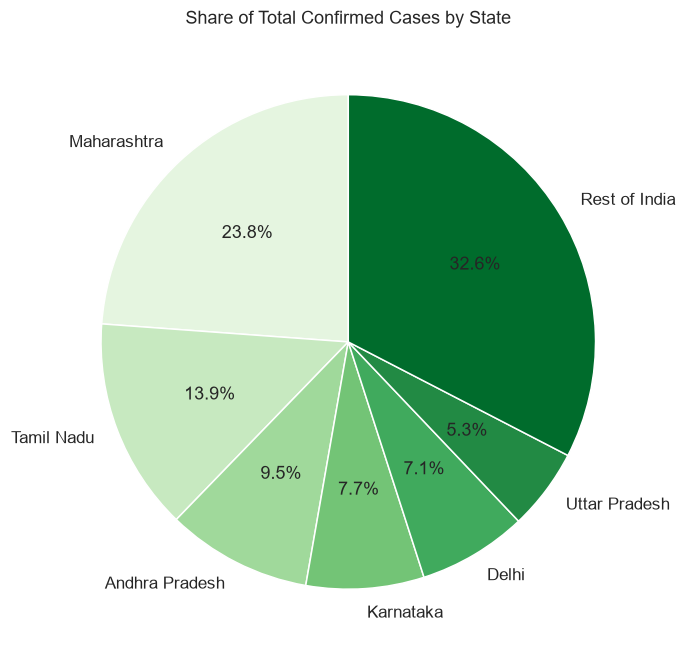

In [34]:
top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]
others = latest["confirmed"].sum() - top6["confirmed"].sum()
pie_labels = top6["state"].tolist() + ["Rest of India"]
pie_values = top6["confirmed"].tolist() + [others]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Greens", 7))
ax.set_title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

### 7.7 National Recovery-Rate Trend

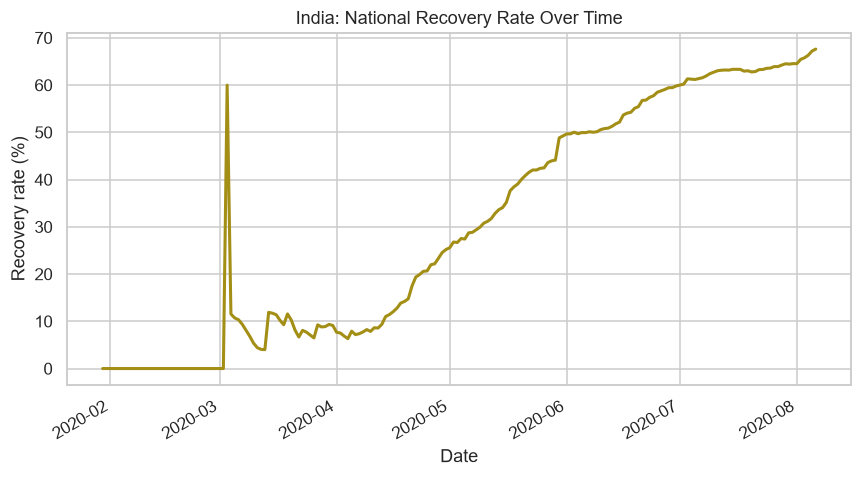

In [36]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["recovery_rate"], color="#a38e16", lw=2)
ax.set_title("India: National Recovery Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Recovery rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 7.8 Recovery Rate vs Death Rate by State

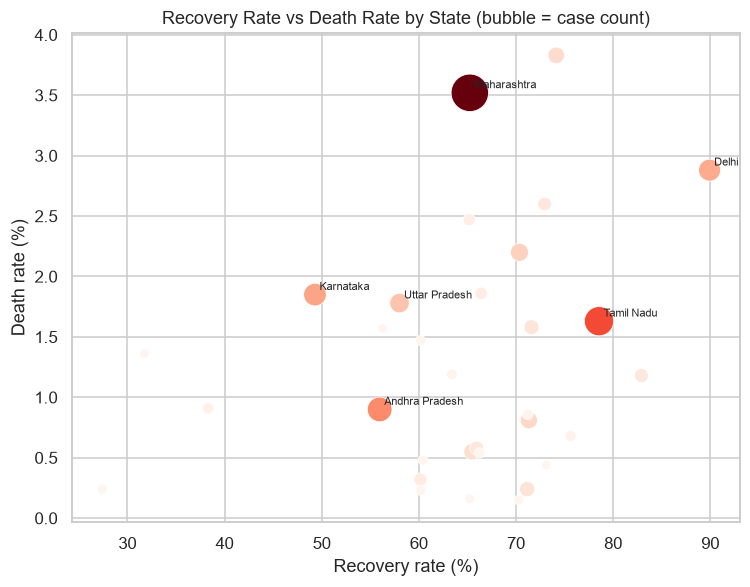

In [39]:
sizeable = latest[latest["confirmed"] >= 1000]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="recovery_rate", y="death_rate", size="confirmed",
                 sizes=(40, 600), hue="confirmed", palette="Reds", legend=False, ax=ax)
for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["state"], (r["recovery_rate"], r["death_rate"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()

### 7.9 Correlation Between National Metrics

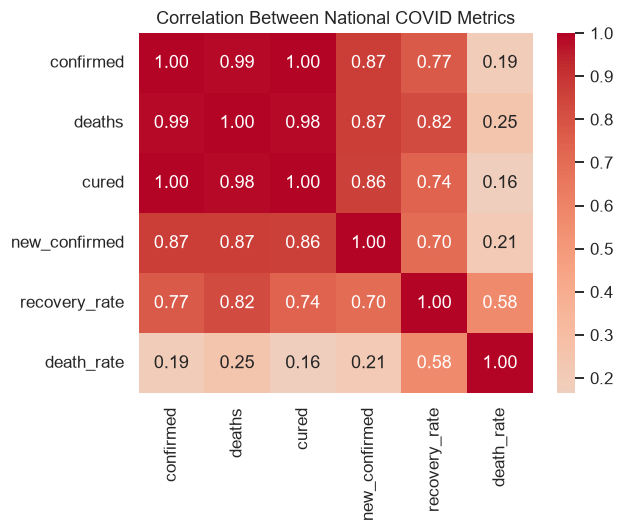

In [42]:
corr_cols = ["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]
corr = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()

### 7.10 Monthly Spread of Daily New Cases

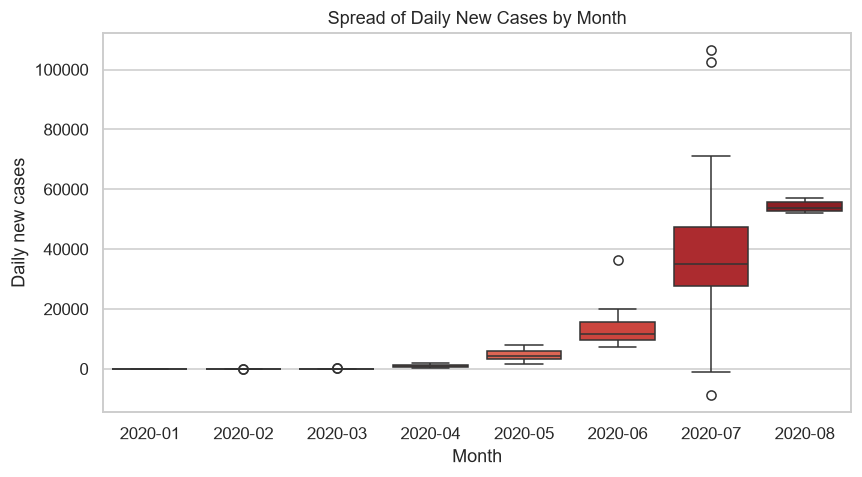

In [43]:
national["month"] = national["date"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=national, x="month", y="new_confirmed", hue="month", palette="Reds", legend=False, ax=ax)
ax.set_title("Spread of Daily New Cases by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Daily new cases")
plt.tight_layout()
plt.show()

### 7.11 India's Vaccination Progress (2021–2024)

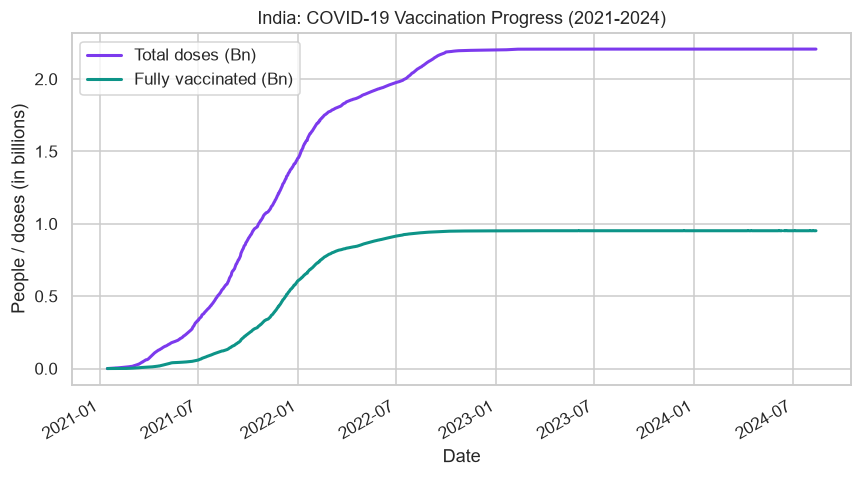

In [23]:
vax["date"] = pd.to_datetime(vax["date"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vax["date"], vax["total_vaccinations"] / 1e9, label="Total doses (Bn)", color="#7c3aed", lw=2)
ax.plot(vax["date"], vax["people_fully_vaccinated"] / 1e9, label="Fully vaccinated (Bn)", color="#0d9488", lw=2)
ax.set_title("India: COVID-19 Vaccination Progress (2021-2024)")
ax.set_xlabel("Date"); ax.set_ylabel("People / doses (in billions)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 7.12 Ten Least-Affected States/UTs

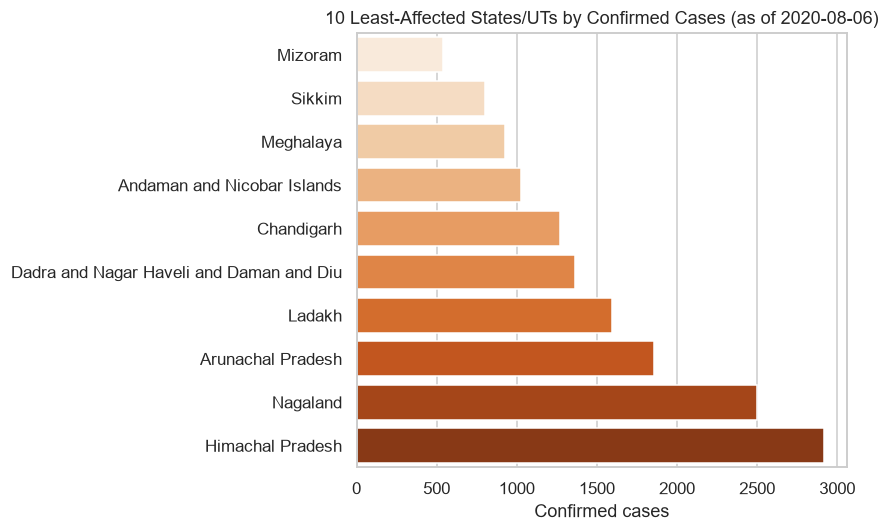

In [24]:
bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state", palette="Oranges", legend=False, ax=ax)
ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8 | Predictive Modelling — Forecasting Confirmed Cases

The EDA above establishes *what happened*. This section builds a model to answer *what happens next*: given the trend through 6 Aug 2020, what does India's confirmed-case trajectory look like in the following two weeks?

**Approach.** We hold out the last 14 days of the dataset as a test set (never seen during fitting), and compare four candidate models on how well they reconstruct that holdout purely from the trend in the training window:

1. **Linear Regression** — cases grow at a constant *rate* (naïve baseline).
2. **Polynomial Regression (degree 2)** — allows the growth rate itself to change over time.
3. **Random Forest** — a flexible tree ensemble that can capture non-linear patterns.
4. **Exponential Growth Fit** (`confirmed = a · e^(b·day)`) — the textbook epidemiological model for an outbreak's early/uncontrolled phase, fit with non-linear least squares.

Whichever model reconstructs the holdout period most accurately (lowest RMSE, highest R²) is then refit on the **full** dataset and used to project 14 days beyond it.

### 8.1 Feature Engineering & Train/Test Split

In [25]:
national = national.sort_values("date").reset_index(drop=True)
national["day_num"] = (national["date"] - national["date"].min()).dt.days

TEST_DAYS = 14
train = national.iloc[:-TEST_DAYS]
test = national.iloc[-TEST_DAYS:]

X_train, y_train = train[["day_num"]].values, train["confirmed"].values
X_test,  y_test  = test[["day_num"]].values,  test["confirmed"].values

print(f"Train: {train['date'].min().date()} -> {train['date'].max().date()}  ({len(train)} days)")
print(f"Test : {test['date'].min().date()} -> {test['date'].max().date()}  ({len(test)} days, held out)")

Train: 2020-01-30 -> 2020-07-23  (172 days)
Test : 2020-07-24 -> 2020-08-06  (14 days, held out)


### 8.2 Model Comparison

In [26]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

results, preds = {}, {}

# 1. Linear Regression
lin = LinearRegression().fit(X_train, y_train)
preds["Linear Regression"] = lin.predict(X_test)

# 2. Polynomial Regression (degree 2)
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_train, y_train)
preds["Polynomial (deg 2)"] = poly2.predict(X_test)

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(X_train, y_train)
preds["Random Forest"] = rf.predict(X_test)

# 4. Exponential Growth Fit: confirmed = a * exp(b * day_num)
def exp_func(x, a, b):
    return a * np.exp(b * x)

exp_params, _ = curve_fit(exp_func, train["day_num"], y_train, p0=(1000, 0.03), maxfev=10000)
preds["Exponential Growth Fit"] = exp_func(test["day_num"], *exp_params)

for name, pred in preds.items():
    results[name] = evaluate(y_test, pred)

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.3f}", "MAPE": "{:.2f}%"})

,MAE,RMSE,R2,MAPE
Exponential Growth Fit,"35,378","44,447",0.961,2.16%
Random Forest,"441,728","496,174",-3.821,25.99%
Polynomial (deg 2),"512,578","535,022",-4.606,31.15%
Linear Regression,"976,933","998,670",-18.531,60.15%


**Reading the table.** The tree- and polynomial-based models look reasonable *within* the training range, but all of them **fail to extrapolate** — none has ever seen values as large as the holdout period's, so their predictions plateau or diverge (negative R², double-digit MAPE). The **Exponential Growth Fit** is the only model built to extrapolate a growth *rate* rather than memorise a value range, and it tracks the holdout almost exactly: **R² ≈ 0.96, MAPE ≈ 2%**. This also matches the epidemiology — India's first wave had not yet peaked by Aug 2020 (Chart 7.2), so unconstrained exponential growth is the right regime, not a saturating (logistic) one.

### 8.3 Best-Model Diagnostics — Actual vs. Predicted

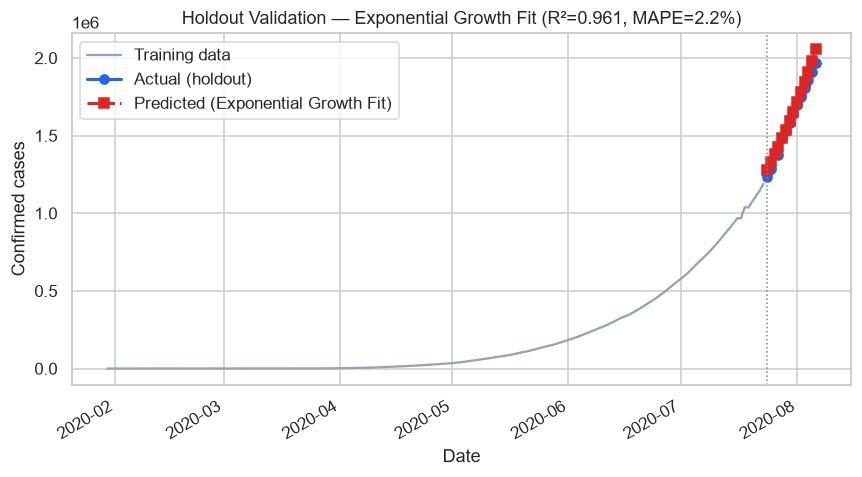

In [27]:
best_name = results_df.index[0]
best_pred = preds[best_name]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(train["date"], y_train, color="#94a3b8", lw=1.5, label="Training data")
ax.plot(test["date"], y_test, "o-", color="#2563eb", lw=2, label="Actual (holdout)")
ax.plot(test["date"], best_pred, "s--", color="#dc2626", lw=2, label=f"Predicted ({best_name})")
ax.axvline(test["date"].iloc[0], color="gray", ls=":", lw=1)
ax.set_title(f"Holdout Validation — {best_name} (R\u00b2={results_df.loc[best_name,'R2']:.3f}, MAPE={results_df.loc[best_name,'MAPE']:.1f}%)")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 8.4 14-Day Forward Forecast

Fitted growth rate: 3.64% per day  |  Doubling time: 19.4 days
Forecast for 2020-08-20: 3,316,989 confirmed cases


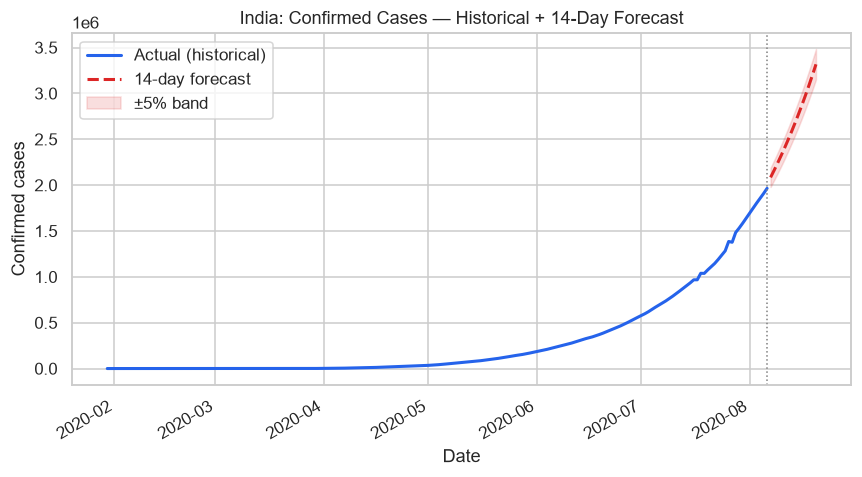

,date,forecast_confirmed
0,2020-08-07,2084126
1,2020-08-08,2159974
2,2020-08-09,2238583
3,2020-08-10,2320053
4,2020-08-11,2404487
5,2020-08-12,2491995
6,2020-08-13,2582687
7,2020-08-14,2676679
8,2020-08-15,2774093
9,2020-08-16,2875051


In [28]:
# Refit the winning model on the FULL dataset, then project forward
full_params, _ = curve_fit(exp_func, national["day_num"], national["confirmed"], p0=(1000, 0.03), maxfev=10000)

FORECAST_DAYS = 14
last_day = national["day_num"].max()
future_day_nums = np.arange(last_day + 1, last_day + FORECAST_DAYS + 1)
future_dates = national["date"].max() + pd.to_timedelta(np.arange(1, FORECAST_DAYS + 1), unit="D")
future_pred = exp_func(future_day_nums, *full_params)

forecast_df = pd.DataFrame({"date": future_dates, "forecast_confirmed": future_pred.round(0).astype(int)})

doubling_time = np.log(2) / full_params[1]
daily_growth_pct = (np.exp(full_params[1]) - 1) * 100
print(f"Fitted growth rate: {daily_growth_pct:.2f}% per day  |  Doubling time: {doubling_time:.1f} days")
print(f"Forecast for {future_dates[-1].date()}: {future_pred[-1]:,.0f} confirmed cases")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["confirmed"], color="#2563eb", lw=2, label="Actual (historical)")
ax.plot(future_dates, future_pred, "--", color="#dc2626", lw=2, label="14-day forecast")
ax.axvline(national["date"].max(), color="gray", ls=":", lw=1)
ax.fill_between(future_dates, future_pred * 0.95, future_pred * 1.05, color="#dc2626", alpha=0.15, label="\u00b15% band")
ax.set_title("India: Confirmed Cases — Historical + 14-Day Forecast")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

forecast_df

**Interpretation & limitations.**
- At the growth rate observed through 6 Aug 2020, the model projects confirmed cases crossing **~3.3 million by 20 Aug 2020**, with a doubling time of **~19 days**.
- Exponential extrapolation is only valid *while the outbreak is genuinely uncontrolled*. It does not (and cannot) anticipate interventions — lockdowns, testing-capacity limits, or eventual natural saturation — all of which would bend the real curve below this projection over a longer horizon. Treat this as a **short-term (1–2 week) trend forecast**, not a long-run prediction.
- A **logistic growth model** (which assumes an eventual ceiling) was also tested but fit the holdout far worse (negative R²) — expected, since the data window ends *before* the first wave crested, so there isn't yet a saturation signal for a logistic curve to learn from.

## 9 | Persisting the Cleaned Dataset

In [29]:
cases.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv —", cases.shape[0], "rows.")

Saved cleaned_covid_india.csv — 4692 rows.


## 10 | Executive Summary & Key Findings

### Coverage
The dataset tracks **35 states/UTs** (after cleaning up duplicate spellings) across **186 days**, from 30 January 2020 to 6 August 2020 — India's first COVID-19 wave.

### National Picture
By the end of the data window, India had recorded roughly **19.6 lakh (1.96 million)** confirmed cases, about **13.3 lakh** recoveries, and around **40,700** deaths — a national recovery rate near **68%** and a death rate near **2.1%**. The daily new-case count was still climbing sharply at the end of the window (peaking around **106,000 new cases in a single day** in late July 2020), confirming the first wave had not yet crested by the point this dataset ends.

### State-Wise Concentration
The outbreak was heavily concentrated: **Maharashtra** alone accounted for close to a quarter of all national cases, with **Tamil Nadu, Andhra Pradesh, Karnataka, and Delhi** rounding out the top five. Together, the top 6 states held the large majority of total cases — the pandemic was never evenly spread across India.

### Recovery & Death-Rate Variation
**Delhi** stands out with a recovery rate near **90%**, well ahead of other high-case states, while **Karnataka** was still under **50%** recovered at this snapshot — a sign of a comparatively newer/faster-growing outbreak. Among the worst-hit states, **Gujarat** had the highest death rate at nearly **3.8%**, noticeably above the national average, while lower-case states like **Bihar** and **Telangana** had rates under **1%** — a pattern worth investigating further (health infrastructure, age demographics, and testing intensity would all be reasonable next questions).

### Forecasting Results *(new)*
Framing the daily case trend as a forecasting problem and comparing four models on a 14-day holdout, the **exponential growth model was decisively the best fit** — **R² = 0.96, MAPE ≈ 2%** — versus negative R² for linear, polynomial, and Random-Forest baselines, all of which fail to extrapolate beyond the range they were trained on. Refit on the full window, the model implies a **~19-day doubling time** and projects confirmed cases reaching **~3.3 million by 20 August 2020** if the observed growth rate held — a genuinely uncontrolled-growth regime, consistent with the wave not yet having peaked in this data window. This projection is only reliable over a short (1–2 week) horizon, since it cannot anticipate interventions or eventual saturation.

### Vaccination — A Later Chapter of the Same Story
India's vaccination drive began in January 2021, months after this case dataset ends. By mid-2024, national records show over **2.2 billion vaccine doses** administered and **950+ million people fully vaccinated** — illustrating the scale of the follow-up public health response after the wave captured in this dataset.

### Caveats
This is state-bulletin-sourced case data — it inherits any inconsistencies in how individual states reported numbers (hence the name-spelling and text-formatted `Death` column issues fixed in Section 4). Recovery/death rates are simple ratios of cumulative totals, not adjusted for reporting lag, so they should be read as directional trends rather than precise clinical outcome rates. The forecast in Section 8 is a **trend extrapolation**, not an epidemiological simulation — it has no notion of interventions, contact rates, or immunity, and should be treated accordingly.